In [2]:
from pathlib import Path

import pandas as pd

df = pd.read_parquet('/Users/yitongzheng/Documents/polymarket/apps/insider_trades/data/market_trades_test.parquet')

In [3]:
df.columns

Index(['timestamp', 'proxyWallet', 'side', 'outcome', 'price', 'size', 'slug',
       'conditionId', 'transactionHash', 'market_question', 'market_slug'],
      dtype='str')

wallet: taker's wallet

side: buy means the taker bought on the ask side.

In [4]:
df.groupby('market_question').size().reset_index(name='num').sort_values('num', ascending=False)

,market_question,num
0,Will Donald Trump win the 2028 US Presidential...,1204


In [6]:
df2 = df[df['market_slug'].str.contains('trump', na=False)][['timestamp', 'proxyWallet', 'side', 'outcome', 'price', 'size']].copy()
df2['timestamp_chicago'] = pd.to_datetime(df2['timestamp'], unit='s', utc=True).dt.tz_convert('America/Chicago')
# direction: 1 means the taker is bullish, -1 means the taker is bearish
df2['direction'] = ((df2['side'] == 'BUY') & (df2['outcome'] == 'Yes')) | ((df2['side'] == 'SELL') & (df2['outcome'] == 'No'))

# convert wallet to A, B, C, etc. Build a mapping first. Take distinct wallets and sort them
wallets = df2['proxyWallet'].unique()
wallet_mapping = {wallet: i for i, wallet in enumerate(wallets)}
df2['wallet'] = df2['proxyWallet'].map(wallet_mapping)
df2.drop(columns=['proxyWallet'], inplace=True)

df2.sort_values('timestamp', ascending=True, inplace=True)

df2[['timestamp_chicago', 'wallet', 'direction', 'size']]

,timestamp_chicago,wallet,direction,size
1203,2026-04-14 23:48:46-05:00,545,True,8.170000
1202,2026-04-14 23:49:56-05:00,24,True,8.170000
1201,2026-04-15 00:51:06-05:00,544,True,36.520000
1200,2026-04-15 01:30:14-05:00,543,True,47.680000
1199,2026-04-15 01:43:50-05:00,542,True,38.180000
...,...,...,...,...
4,2026-04-21 22:57:46-05:00,2,False,8.273000
3,2026-04-21 23:15:42-05:00,3,False,51.550000
2,2026-04-21 23:16:24-05:00,2,True,8.280000
1,2026-04-21 23:22:22-05:00,1,True,29.411763


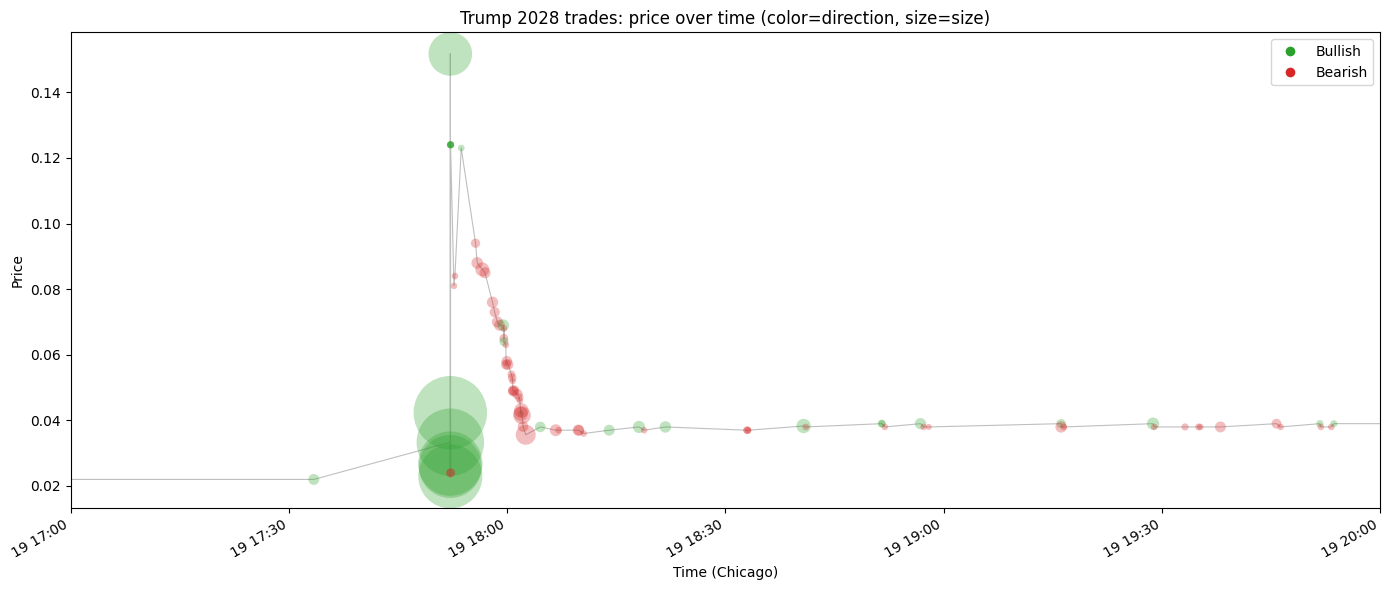

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 6))

colors = df2['direction'].map({True: 'tab:green', False: 'tab:red'})
yes_price = df2['price'].where(df2['outcome'] == 'Yes', 1 - df2['price'])

ax.plot(
    df2['timestamp_chicago'],
    yes_price,
    color='gray',
    linewidth=0.8,
    alpha=0.5,
    zorder=1,
)

ax.scatter(
    df2['timestamp_chicago'],
    yes_price,
    c=colors,
    s=np.sqrt(df2['size'])*10,
    alpha=0.3,
    edgecolors='none',
)

ax.set_xlabel('Time (Chicago)')
ax.set_ylabel('Price')
ax.set_title('Trump 2028 trades: price over time (color=direction, size=size)')

ax.set_xlim(
    pd.Timestamp('2026-04-19 17:00', tz='America/Chicago'),
    pd.Timestamp('2026-04-19 20:00', tz='America/Chicago'),
)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', markersize=8, label='Bullish'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=8, label='Bearish'),
]
ax.legend(handles=legend_elements, loc='best')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()